# Quantum Kernel SVM for Forbush Decrease Classification
## Analysis of Experiments — Paper Results

**Dataset:** FEID + OMNI + NMDB (JUNG station)  
**Models:** RBF-SVM (full), RBF-SVM (sub), Quantum Kernel SVM (ZZFeatureMap)  
**Comparison metric:** ΔAUC = AUC_QSVM − AUC_RBF_sub (fair comparison, same n)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "font.size"        : 11,
    "axes.titlesize"   : 12,
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "legend.fontsize"  : 10,
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

C_QSVM    = "#2166ac"
C_RBF_SUB = "#d6604d"
C_RBF_FUL = "#4dac26"
C_ZERO    = "#888888"
CMAP_DIV  = "RdBu_r"

print("Libraries loaded OK")

Libraries loaded OK


## 1. Load and Clean Data

In [2]:
df_raw = pd.read_csv("AllExperiments.csv", index_col=0)
print(f"Raw rows: {len(df_raw)}")

df = df_raw.drop_duplicates(subset=["min_magn","n_qubits","reps","n_train_quantum"])
print(f"After dedup: {len(df)} experiments")

# Map truncated max_q to nominal values for grouping
# Each min_magn has a max available n due to fewer FD events
maxq_map = {51:50, 97:100, 70:50, 160:150}
df["max_q_nom"] = df["n_train_quantum"].replace(maxq_map)

print(f"\nmin_magn values : {sorted(df['min_magn'].unique())}")
print(f"n_qubits values : {sorted(df['n_qubits'].unique())}")
print(f"reps values     : {sorted(df['reps'].unique())}")
print(f"max_q_nom values: {sorted(df['max_q_nom'].unique())}")

# Labels
magn_labels = {0.0:"≥0%", 3.0:"≥3%", 4.0:"≥4%", 5.0:"≥5%", 6.0:"≥6%", 7.0:"≥7%"}
magn_colors = {
    0.0:"#bdbdbd", 3.0:"#fdae61", 4.0:"#f4a582",
    5.0:"#2166ac", 6.0:"#4393c3", 7.0:"#d73027"
}
magns = sorted(df["min_magn"].unique())
df.head()

Raw rows: 270
After dedup: 180 experiments

min_magn values : [np.float64(0.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]
n_qubits values : [np.int64(4), np.int64(6), np.int64(8)]
reps values     : [np.int64(1), np.int64(2), np.int64(3)]
max_q_nom values: [np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(250)]


,n_total,n_fd,n_nofd,n_train_full,n_train_quantum,n_test,n_qubits,reps,C,min_magn,auc_rbf_full,acc_rbf_full,auc_rbf_sub,acc_rbf_sub,auc_qsvm,acc_qsvm,delta_auc_fair,delta_auc_full,File,max_q_nom
0,5942,2971,2971,4456,100,1486,4,1,1.0,0.0,0.861327,0.822342,0.853556,0.815612,0.798413,0.728802,-0.055144,-0.062914,Results/exp_0.0_4_1_100.csv,100
0,5942,2971,2971,4456,150,1486,4,1,1.0,0.0,0.861327,0.822342,0.855221,0.815612,0.786565,0.726783,-0.068656,-0.074761,Results/exp_0.0_4_1_150.csv,150
0,5942,2971,2971,4456,200,1486,4,1,1.0,0.0,0.861327,0.822342,0.853341,0.815612,0.808692,0.736205,-0.044649,-0.052635,Results/exp_0.0_4_1_200.csv,200
0,5942,2971,2971,4456,250,1486,4,1,1.0,0.0,0.861327,0.822342,0.853558,0.814266,0.817090,0.745626,-0.036469,-0.044237,Results/exp_0.0_4_1_250.csv,250
0,5942,2971,2971,4456,50,1486,4,1,1.0,0.0,0.861327,0.822342,0.852380,0.808883,0.738407,0.660834,-0.113973,-0.122919,Results/exp_0.0_4_1_50.csv,50


## 2. Global Summary Statistics

In [3]:
print("="*60)
print("  GLOBAL SUMMARY")
print("="*60)

n = len(df)
wins   = (df["delta_auc_fair"] > 0.01).sum()
parity = (df["delta_auc_fair"].abs() <= 0.01).sum()
loses  = (df["delta_auc_fair"] < -0.01).sum()

print(f"  Total valid experiments : {n}")
print(f"  QSVM > RBF_sub (>+0.01): {wins}  ({100*wins/n:.1f}%)")
print(f"  Parity (|ΔAUC|≤0.01)   : {parity}  ({100*parity/n:.1f}%)")
print(f"  QSVM < RBF_sub (<-0.01): {loses}  ({100*loses/n:.1f}%)")
print()
print(f"  ΔAUC: mean={df['delta_auc_fair'].mean():+.4f}  "
      f"median={df['delta_auc_fair'].median():+.4f}  "
      f"std={df['delta_auc_fair'].std():.4f}")
print()
for col, name in [("auc_rbf_full","RBF-SVM (full)"),
                   ("auc_rbf_sub", "RBF-SVM (sub) "),
                   ("auc_qsvm",    "Quantum Kernel")]:
    print(f"  {name}: mean={df[col].mean():.4f} ± {df[col].std():.4f}  "
          f"[{df[col].min():.4f}, {df[col].max():.4f}]")

  GLOBAL SUMMARY
  Total valid experiments : 180
  QSVM > RBF_sub (>+0.01): 73  (40.6%)
  Parity (|ΔAUC|≤0.01)   : 13  (7.2%)
  QSVM < RBF_sub (<-0.01): 94  (52.2%)

  ΔAUC: mean=+0.0021  median=-0.0139  std=0.0827

  RBF-SVM (full): mean=0.8874 ± 0.0374  [0.8011, 0.9306]
  RBF-SVM (sub) : mean=0.8802 ± 0.0401  [0.7997, 0.9306]
  Quantum Kernel: mean=0.8823 ± 0.0818  [0.6547, 1.0000]


## 3. Effect of FD Magnitude Threshold (min_magn)

In [4]:
summary_magn = []
for m in magns:
    s = df[df["min_magn"]==m]
    summary_magn.append({
        "min_magn"    : m,
        "label"       : magn_labels[m],
        "n"           : len(s),
        "n_fd_events" : s["n_fd"].iloc[0],
        "AUC_RBF_full": s["auc_rbf_full"].mean(),
        "AUC_RBF_sub" : s["auc_rbf_sub"].mean(),
        "AUC_QSVM"    : s["auc_qsvm"].mean(),
        "ΔAUC_mean"   : s["delta_auc_fair"].mean(),
        "ΔAUC_std"    : s["delta_auc_fair"].std(),
        "Q>C (%)"     : 100*(s["delta_auc_fair"]>0).mean(),
    })

sm = pd.DataFrame(summary_magn)
print(sm.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

 min_magn label  n  n_fd_events  AUC_RBF_full  AUC_RBF_sub  AUC_QSVM  ΔAUC_mean  ΔAUC_std  Q>C (%)
   0.0000   ≥0% 45         2971        0.8763       0.8572    0.7574    -0.0998    0.0426   0.0000
   3.0000   ≥3% 45          190        0.9199       0.9155    0.8906    -0.0250    0.0176   8.8889
   4.0000   ≥4% 36          107        0.8592       0.8504    0.9205     0.0701    0.0662  72.2222
   5.0000   ≥5% 18           65        0.8897       0.8943    0.9685     0.0742    0.0268 100.0000
   6.0000   ≥6% 18           47        0.8634       0.8634    0.9506     0.0872    0.0390 100.0000
   7.0000   ≥7% 18           34        0.9120       0.9120    0.9429     0.0309    0.0435  55.5556


## 4. Figure 1 — Main Result: AUC and ΔAUC by min_magn

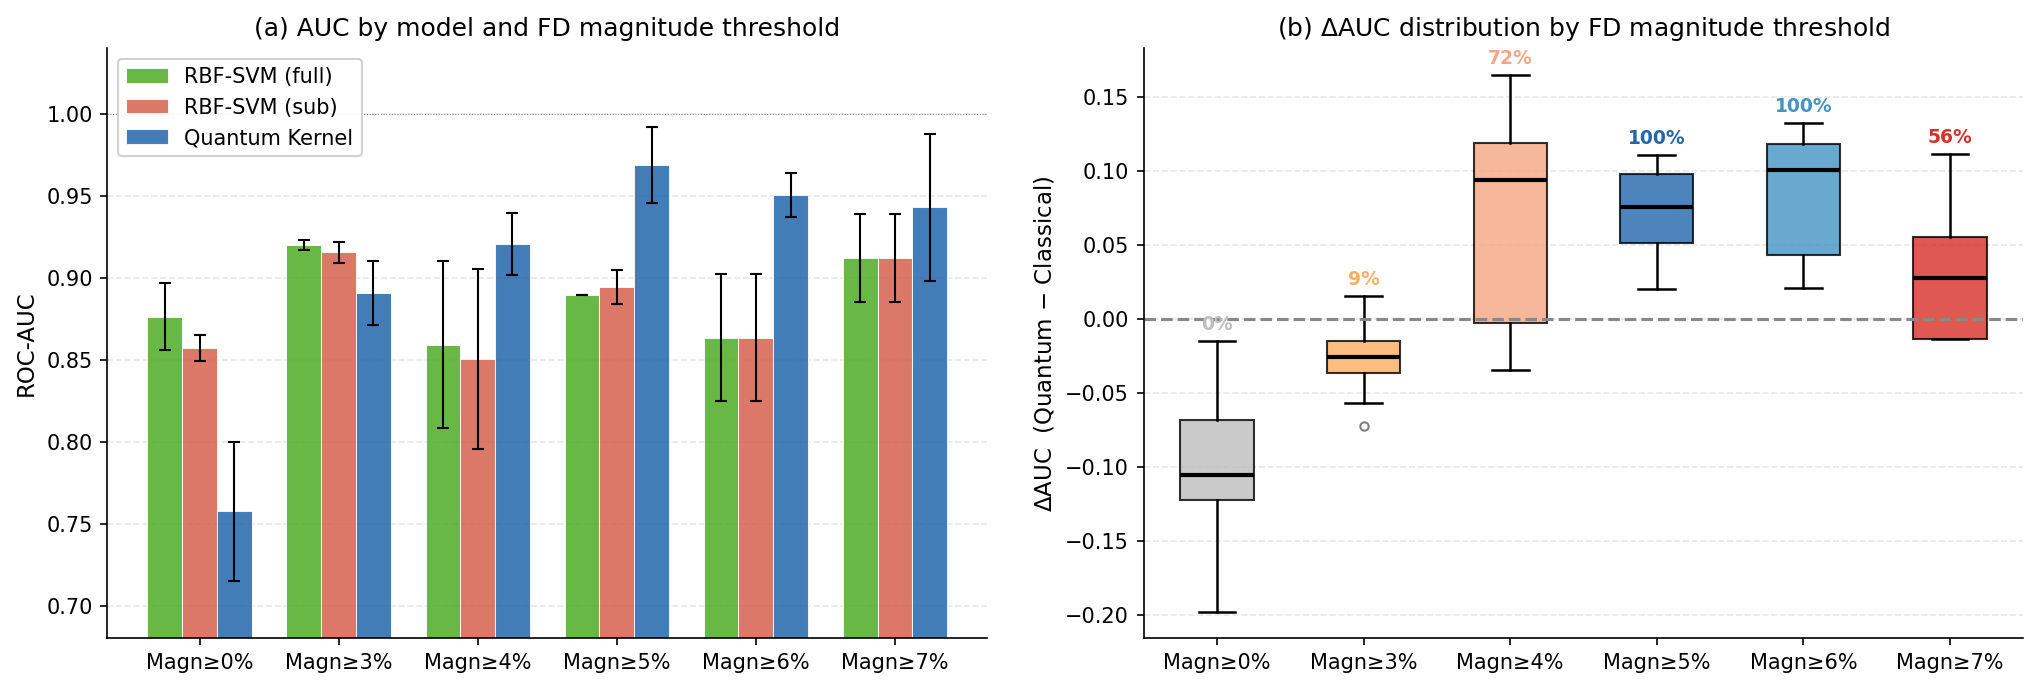

Figure 1 saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: grouped bar chart ────────────────────────────────────────────────
ax = axes[0]
x = np.arange(len(magns))
w = 0.25

for i, (col, label, color) in enumerate([
    ("auc_rbf_full", "RBF-SVM (full)",  C_RBF_FUL),
    ("auc_rbf_sub",  "RBF-SVM (sub)",   C_RBF_SUB),
    ("auc_qsvm",     "Quantum Kernel",   C_QSVM),
]):
    means = [df[df["min_magn"]==m][col].mean() for m in magns]
    stds  = [df[df["min_magn"]==m][col].std()  for m in magns]
    ax.bar(x + (i-1)*w, means, w, label=label, color=color,
           alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.errorbar(x + (i-1)*w, means, yerr=stds, fmt="none",
                color="black", capsize=3, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels([f"Magn{magn_labels[m]}" for m in magns])
ax.set_ylabel("ROC-AUC")
ax.set_title("(a) AUC by model and FD magnitude threshold")
ax.set_ylim(0.68, 1.04)
ax.legend(loc="upper left", framealpha=0.9)
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle=":")

# ── Panel B: boxplot ΔAUC ────────────────────────────────────────────────────
ax = axes[1]
data_box = [df[df["min_magn"]==m]["delta_auc_fair"].values for m in magns]
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker="o", markersize=4, alpha=0.5))

for patch, m in zip(bp["boxes"], magns):
    patch.set_facecolor(magn_colors[m])
    patch.set_alpha(0.8)

ax.axhline(0, color=C_ZERO, linewidth=1.5, linestyle="--")
ax.set_xticks(range(1, len(magns)+1))
ax.set_xticklabels([f"Magn{magn_labels[m]}" for m in magns])
ax.set_ylabel(r"$\Delta$AUC  (Quantum − Classical)")
ax.set_title(r"(b) $\Delta$AUC distribution by FD magnitude threshold")
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

for i, m in enumerate(magns):
    s   = df[df["min_magn"]==m]
    pct = 100*(s["delta_auc_fair"]>0).mean()
    ax.text(i+1, s["delta_auc_fair"].max()+0.005, f"{pct:.0f}%",
            ha="center", va="bottom", fontsize=9,
            color=magn_colors[m], fontweight="bold")

plt.tight_layout(pad=2)
plt.savefig("fig1_main_result.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 1 saved")

## 5. Figure 2 — Heatmaps: ΔAUC by parameter combinations

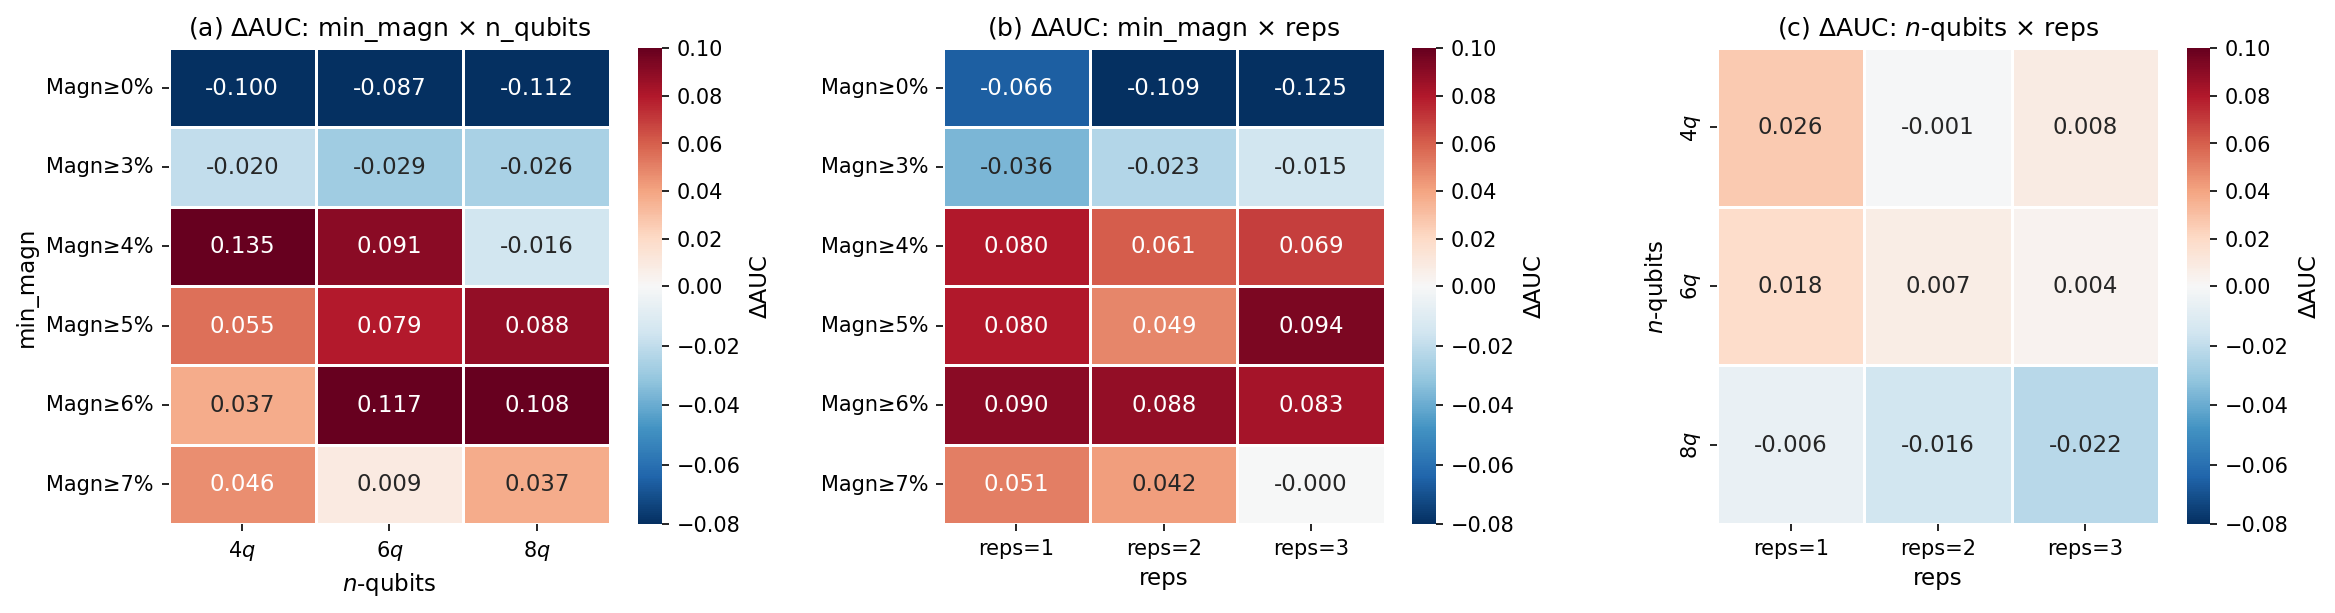

Figure 2 saved


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
norm = TwoSlopeNorm(vmin=-0.08, vcenter=0, vmax=0.10)
kw   = dict(annot=True, fmt=".3f", cmap=CMAP_DIV, norm=norm,
            linewidths=0.5, linecolor="white", cbar_kws={"label":"ΔAUC"})

# Panel A: (min_magn × n_qubits)
pivot1 = df.groupby(["min_magn","n_qubits"])["delta_auc_fair"].mean().unstack()
pivot1.index = [f"Magn{magn_labels[m]}" for m in pivot1.index]
pivot1.columns = [f"{q}$q$" for q in pivot1.columns]
sns.heatmap(pivot1, ax=axes[0], **kw)
axes[0].set_title(r"(a) $\Delta$AUC: min_magn × n_qubits")
axes[0].set_xlabel(r"$n$-qubits"); axes[0].set_ylabel("min_magn")

# Panel B: (min_magn × reps)
pivot2 = df.groupby(["min_magn","reps"])["delta_auc_fair"].mean().unstack()
pivot2.index = [f"Magn{magn_labels[m]}" for m in pivot2.index]
pivot2.columns = [f"reps={r}" for r in pivot2.columns]
sns.heatmap(pivot2, ax=axes[1], **kw)
axes[1].set_title(r"(b) $\Delta$AUC: min_magn $\times$ reps")
axes[1].set_xlabel("reps"); axes[1].set_ylabel("")

# Panel C: (n_qubits × reps)
pivot3 = df.groupby(["n_qubits","reps"])["delta_auc_fair"].mean().unstack()
pivot3.index = [f"{q}$q$" for q in pivot3.index]
pivot3.columns = [f"reps={r}" for r in pivot3.columns]
sns.heatmap(pivot3, ax=axes[2], **kw)
axes[2].set_title(r"(c) $\Delta$AUC: $n$-qubits $\times$ reps")
axes[2].set_xlabel("reps"); axes[2].set_ylabel(r"$n$-qubits")

plt.tight_layout(pad=2)
plt.savefig("fig2_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 2 saved")

## 6. Figure 3 — Learning Curve: ΔAUC vs. training size

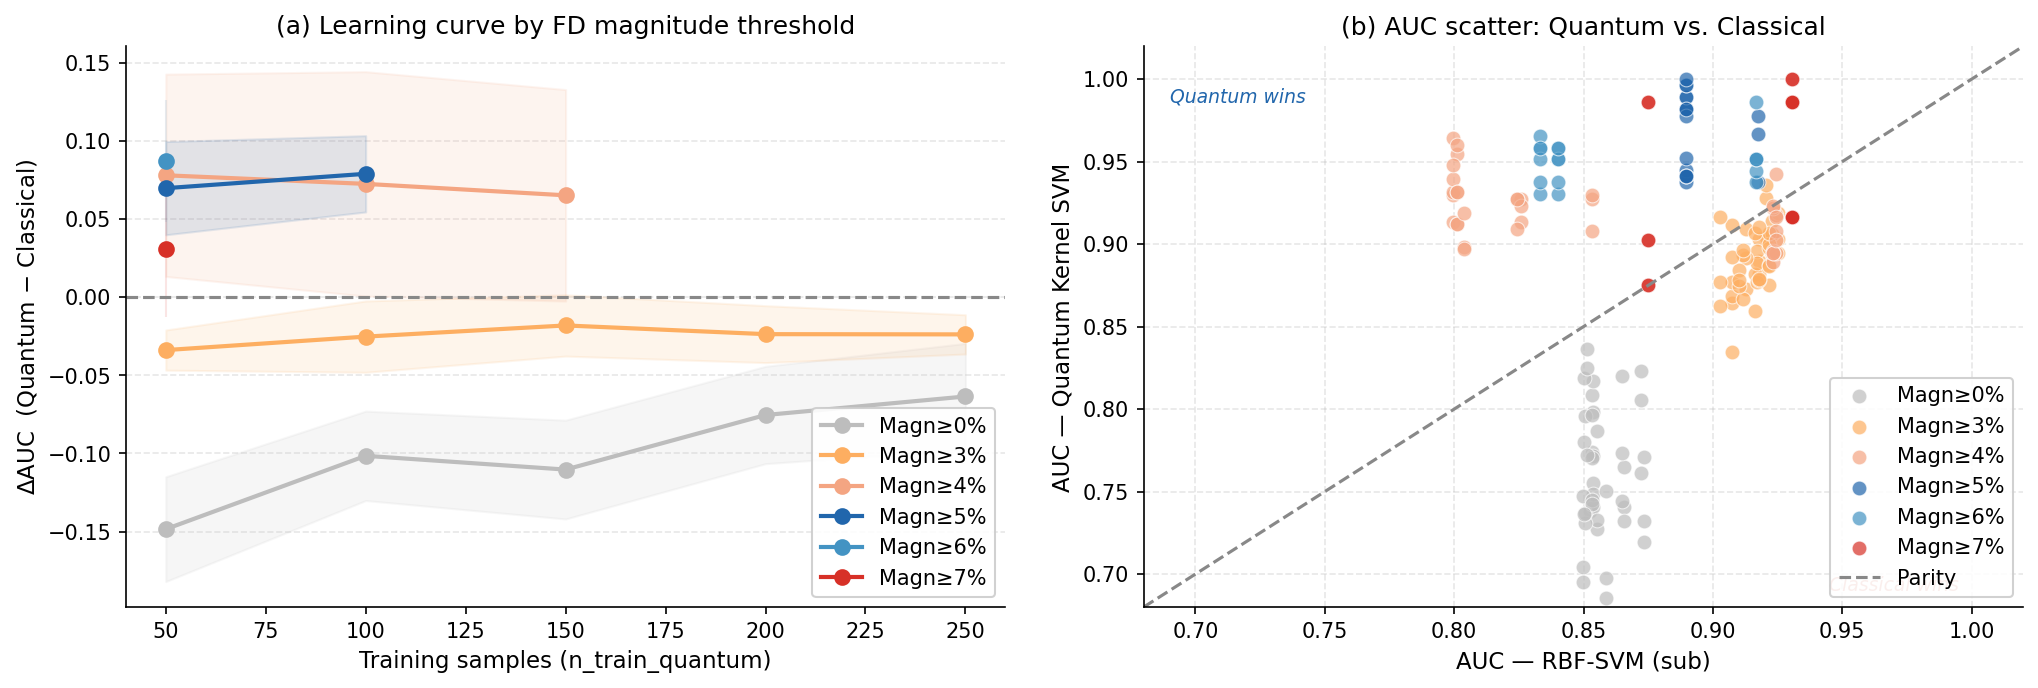

Figure 3 saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: learning curve por min_magn ─────────────────────────────────────
ax = axes[0]
for m in magns:
    sub = df[df["min_magn"]==m].groupby("max_q_nom").agg(
        auc_q=("auc_qsvm","mean"),
        auc_c=("auc_rbf_sub","mean"),
        delta=("delta_auc_fair","mean"),
        std=("delta_auc_fair","std"),
    ).reset_index()
    ax.plot(sub["max_q_nom"], sub["delta"], "o-",
            color=magn_colors[m], label=f"Magn{magn_labels[m]}",
            linewidth=2, markersize=7)
    ax.fill_between(sub["max_q_nom"],
                    sub["delta"]-sub["std"],
                    sub["delta"]+sub["std"],
                    alpha=0.12, color=magn_colors[m])

ax.axhline(0, color=C_ZERO, linewidth=1.5, linestyle="--")
ax.set_xlabel("Training samples (n_train_quantum)")
ax.set_ylabel(r"$\Delta$AUC  (Quantum − Classical)")
ax.set_title("(a) Learning curve by FD magnitude threshold")
ax.legend(framealpha=0.9, loc="lower right")
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# ── Panel B: AUC_QSVM vs AUC_RBF_sub por min_magn ───────────────────────────
ax = axes[1]
for m in magns:
    sub = df[df["min_magn"]==m]
    ax.scatter(sub["auc_rbf_sub"], sub["auc_qsvm"],
               color=magn_colors[m], label=f"Magn{magn_labels[m]}",
               alpha=0.7, s=50, edgecolors="white", linewidths=0.5)

lims = [0.68, 1.02]
ax.plot(lims, lims, "--", color=C_ZERO, linewidth=1.5, label="Parity")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("AUC — RBF-SVM (sub)")
ax.set_ylabel("AUC — Quantum Kernel SVM")
ax.set_title("(b) AUC scatter: Quantum vs. Classical")
ax.legend(framealpha=0.9, loc="lower right")
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.xaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# Anotar cuadrantes
ax.text(0.69, 0.995, "Quantum wins", fontsize=9, color="#2166ac",
        fontstyle="italic", va="top")
ax.text(0.995, 0.69, "Classical wins", fontsize=9, color="#d6604d",
        fontstyle="italic", ha="right")

plt.tight_layout(pad=2)
plt.savefig("fig3_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 3 saved")

## 7. Figure 4 — Effect of Circuit Architecture

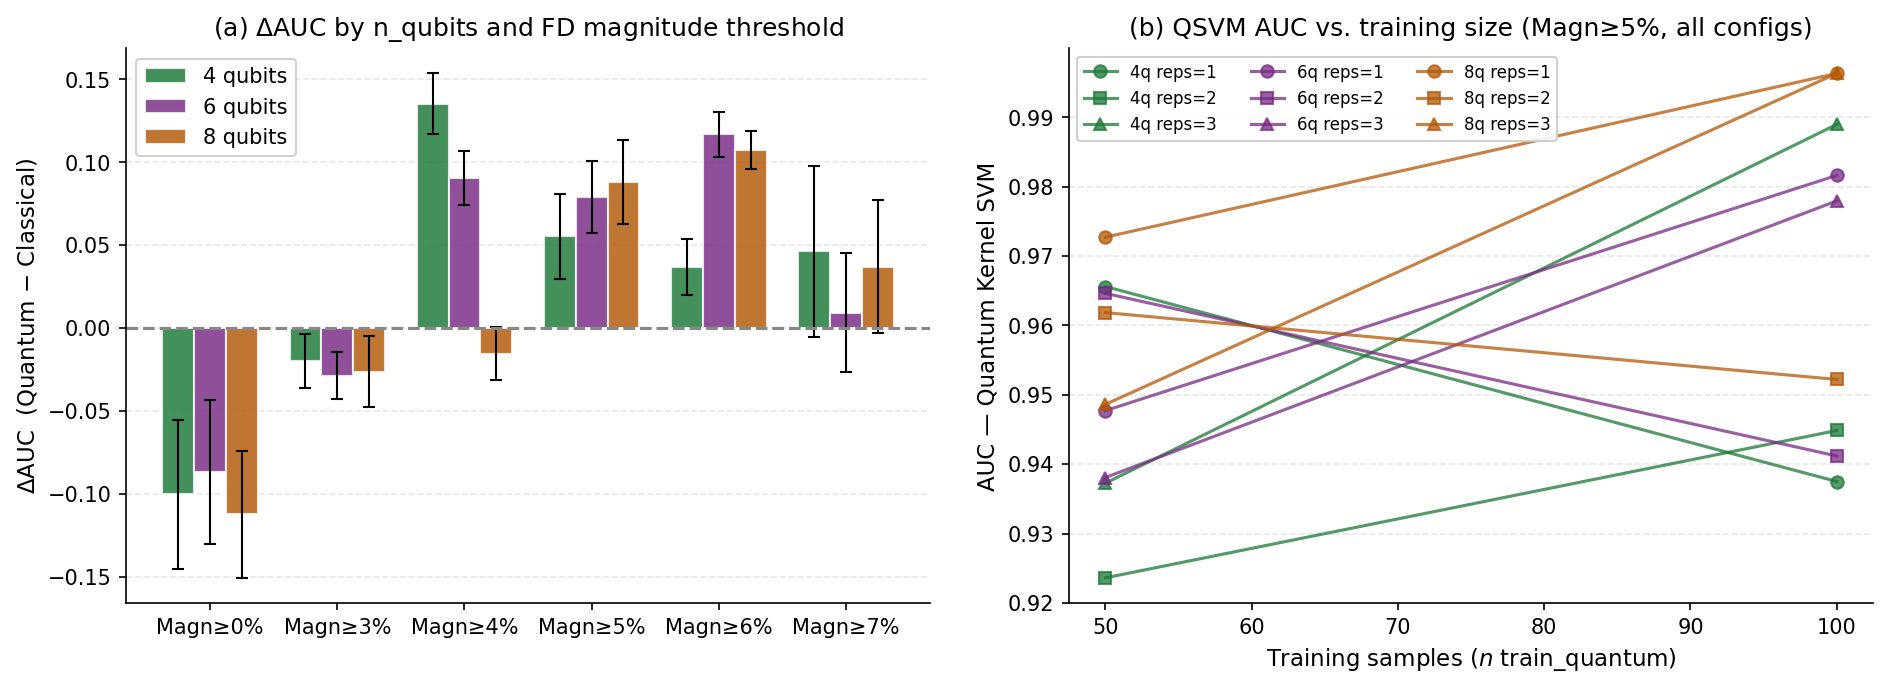

Figure 4 saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
q_colors = {4:"#1b7837", 6:"#762a83", 8:"#b35806"}
r_markers = {1:"o", 2:"s", 3:"^"}

# ── Panel A: ΔAUC por n_qubits, separado por min_magn ────────────────────────
ax = axes[0]
x  = np.arange(len(magns))
w  = 0.25
for i, q in enumerate([4, 6, 8]):
    means = [df[(df["min_magn"]==m)&(df["n_qubits"]==q)]["delta_auc_fair"].mean()
             for m in magns]
    stds  = [df[(df["min_magn"]==m)&(df["n_qubits"]==q)]["delta_auc_fair"].std()
             for m in magns]
    ax.bar(x+(i-1)*w, means, w, label=f"{q} qubits",
           color=q_colors[q], alpha=0.82, edgecolor="white")
    ax.errorbar(x+(i-1)*w, means, yerr=stds, fmt="none",
                color="black", capsize=3, linewidth=1)

ax.axhline(0, color=C_ZERO, linewidth=1.5, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([f"Magn{magn_labels[m]}" for m in magns])
ax.set_ylabel(r"$\Delta$AUC  (Quantum − Classical)")
ax.set_title(r"(a) $\Delta$AUC by n_qubits and FD magnitude threshold")
ax.legend(framealpha=0.9)
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# ── Panel B: AUC_QSVM vs max_q por (n_qubits, reps) solo min_magn>=5 ─────────
ax = axes[1]
df_best = df[df["min_magn"]>=5.0]
for q in [4, 6, 8]:
    for r in [1, 2, 3]:
        sub = df_best[(df_best["n_qubits"]==q)&(df_best["reps"]==r)]
        sub = sub.groupby("max_q_nom")["auc_qsvm"].mean().reset_index()
        if len(sub) > 0:
            ax.plot(sub["max_q_nom"], sub["auc_qsvm"],
                    marker=r_markers[r], color=q_colors[q],
                    linewidth=1.5, markersize=6, alpha=0.75,
                    label=f"{q}q reps={r}")

ax.set_xlabel(r"Training samples ($n$ train_quantum)")
ax.set_ylabel("AUC — Quantum Kernel SVM")
ax.set_title("(b) QSVM AUC vs. training size (Magn≥5%, all configs)")
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.legend(fontsize=8, ncol=3, framealpha=0.9)

plt.tight_layout(pad=2)
plt.savefig("fig4_architecture.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 4 saved")

## 8. Figure 5 — Quantum Advantage Transition

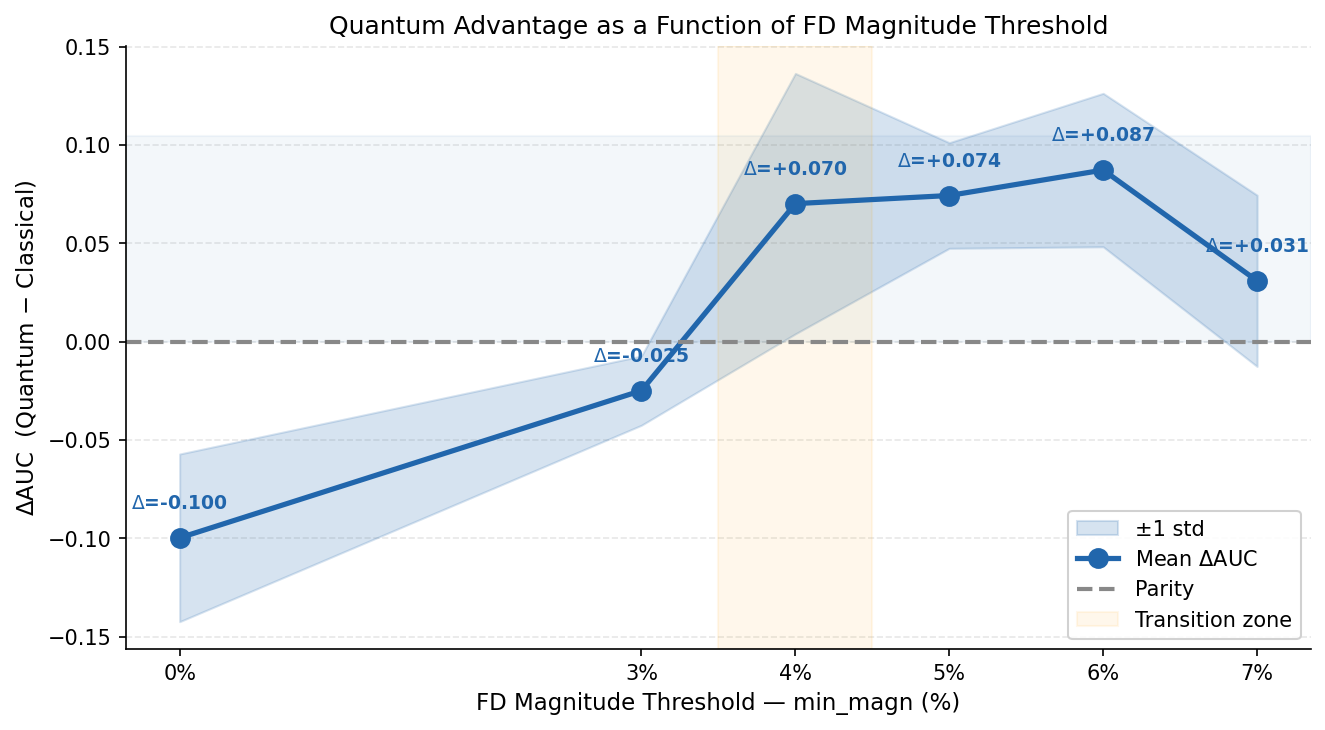

Figure 5 saved


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# ΔAUC medio y std por min_magn (promedio sobre todos los parámetros)
grp = df.groupby("min_magn")["delta_auc_fair"].agg(["mean","std","count"]).reset_index()
grp.columns = ["min_magn","mean","std","count"]

ax.fill_between(grp["min_magn"],
                grp["mean"] - grp["std"],
                grp["mean"] + grp["std"],
                alpha=0.18, color=C_QSVM, label="±1 std")
ax.plot(grp["min_magn"], grp["mean"], "o-",
        color=C_QSVM, linewidth=2.5, markersize=9, label=r"Mean $\Delta$AUC")

# Región de ventaja cuántica
ax.axhspan(0, grp["mean"].max()*1.2, alpha=0.05, color=C_QSVM)
ax.axhline(0, color=C_ZERO, linewidth=2, linestyle="--", label="Parity")

# Anotar cada punto
for _, row in grp.iterrows():
    ax.annotate(f"$\Delta$={row['mean']:+.3f}",
                xy=(row["min_magn"], row["mean"]),
                xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=9, color=C_QSVM, fontweight="bold")

# Zona de transición
ax.axvspan(3.5, 4.5, alpha=0.08, color="orange", label="Transition zone")
ax.set_xlabel("FD Magnitude Threshold — min_magn (%)")
ax.set_ylabel(r"$\Delta$AUC  (Quantum − Classical)")
ax.set_title("Quantum Advantage as a Function of FD Magnitude Threshold")
ax.legend(framealpha=0.9)
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.set_xticks(grp["min_magn"])
ax.set_xticklabels([f"{m:.0f}%" for m in grp["min_magn"]])

plt.tight_layout()
plt.savefig("fig5_transition.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 5 saved")

## 9. Table 1 — Summary Table for Paper

In [10]:
rows = []
for m in magns:
    for q in sorted(df["n_qubits"].unique()):
        sub = df[(df["min_magn"]==m) & (df["n_qubits"]==q)]
        if len(sub) == 0:
            continue
        wins = (sub["delta_auc_fair"] > 0).sum()
        rows.append({
            "min_magn"    : m,
            "Threshold"   : f"Magn{magn_labels[m]}",
            "n_qubits"    : q,
            "n_exp"       : len(sub),
            "AUC_RBF_full": f"{sub['auc_rbf_full'].mean():.4f}",
            "AUC_RBF_sub" : f"{sub['auc_rbf_sub'].mean():.4f}",
            "AUC_QSVM"    : f"{sub['auc_qsvm'].mean():.4f}",
            "ΔAUC"        : f"{sub['delta_auc_fair'].mean():+.4f}",
            "±std"        : f"{sub['delta_auc_fair'].std():.4f}",
            "Q>C"         : f"{wins}/{len(sub)} ({100*wins/len(sub):.0f}%)",
        })

table = pd.DataFrame(rows)
print(table.drop(columns=["min_magn"]).to_string(index=False))
print("\n→ Save to LaTeX:")
print(table.drop(columns=["min_magn"]).to_latex(index=False, escape=True))

Threshold  n_qubits  n_exp AUC_RBF_full AUC_RBF_sub AUC_QSVM    ΔAUC   ±std          Q>C
  Magn≥0%         4     15       0.8613      0.8536   0.7533 -0.1003 0.0450    0/15 (0%)
  Magn≥0%         6     15       0.8627      0.8511   0.7642 -0.0868 0.0432    0/15 (0%)
  Magn≥0%         8     15       0.9049      0.8670   0.7547 -0.1123 0.0384    0/15 (0%)
  Magn≥3%         4     15       0.9242      0.9188   0.8989 -0.0199 0.0166   2/15 (13%)
  Magn≥3%         6     15       0.9180      0.9178   0.8891 -0.0287 0.0143    0/15 (0%)
  Magn≥3%         8     15       0.9176      0.9100   0.8838 -0.0262 0.0213   2/15 (13%)
  Magn≥4%         4     12       0.8011      0.8004   0.9358 +0.1353 0.0183 12/12 (100%)
  Magn≥4%         6     12       0.8532      0.8268   0.9174 +0.0905 0.0162 12/12 (100%)
  Magn≥4%         8     12       0.9232      0.9239   0.9083 -0.0155 0.0159   2/12 (17%)
  Magn≥5%         4      6       0.8897      0.9035   0.9589 +0.0555 0.0256   6/6 (100%)
  Magn≥5%         6  

## 10. Statistical Tests

In [11]:
print("=== Wilcoxon signed-rank test: QSVM vs RBF_sub ===")
print("(tests if ΔAUC is significantly different from zero)\n")

for m in magns:
    sub = df[df["min_magn"]==m]["delta_auc_fair"].values
    stat, pval = stats.wilcoxon(sub, alternative="greater")
    sig = "***" if pval<0.001 else ("**" if pval<0.01 else ("*" if pval<0.05 else "ns"))
    print(f"  Magn{magn_labels[m]:5s}  W={stat:.1f}  p={pval:.4f}  {sig}")

print("\n=== Kruskal-Wallis: ΔAUC across min_magn groups ===")
groups = [df[df["min_magn"]==m]["delta_auc_fair"].values for m in magns]
stat, pval = stats.kruskal(*groups)
print(f"  H={stat:.3f}  p={pval:.6f}")
if pval < 0.05:
    print("  → Significant differences across min_magn groups (p<0.05)")

=== Wilcoxon signed-rank test: QSVM vs RBF_sub ===
(tests if ΔAUC is significantly different from zero)

  Magn≥0%    W=0.0  p=1.0000  ns
  Magn≥3%    W=25.5  p=1.0000  ns
  Magn≥4%    W=595.0  p=0.0000  ***
  Magn≥5%    W=171.0  p=0.0001  ***
  Magn≥6%    W=171.0  p=0.0001  ***
  Magn≥7%    W=115.0  p=0.0071  **

=== Kruskal-Wallis: ΔAUC across min_magn groups ===
  H=138.198  p=0.000000
  → Significant differences across min_magn groups (p<0.05)


## 11. Best Configuration Summary

In [12]:
print("=== TOP 15 EXPERIMENTS by ΔAUC ===\n")
top = df.nlargest(15, "delta_auc_fair")[[
    "min_magn","n_qubits","reps","n_train_quantum",
    "auc_rbf_sub","auc_qsvm","delta_auc_fair"
]]
top.columns = ["min_magn","n_qubits","reps","n_train_q",
               "AUC_RBF","AUC_QSVM","ΔAUC"]
print(top.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== WINNING REGION: min_magn>=5, n_qubits in {4,6} ===")
best = df[(df["min_magn"]>=5.0) & (df["n_qubits"].isin([4,6]))]
print(f"  n={len(best)} experiments")
print(f"  AUC_QSVM = {best['auc_qsvm'].mean():.4f} ± {best['auc_qsvm'].std():.4f}")
print(f"  AUC_RBF  = {best['auc_rbf_sub'].mean():.4f} ± {best['auc_rbf_sub'].std():.4f}")
print(f"  ΔAUC     = {best['delta_auc_fair'].mean():+.4f} ± {best['delta_auc_fair'].std():.4f}")
print(f"  Q>C      = {(best['delta_auc_fair']>0).sum()}/{len(best)} "
      f"({100*(best['delta_auc_fair']>0).mean():.0f}%)")

=== TOP 15 EXPERIMENTS by ΔAUC ===

 min_magn  n_qubits  reps  n_train_q  AUC_RBF  AUC_QSVM   ΔAUC
   4.0000         4     1        100   0.7997    0.9643 0.1646
   4.0000         4     1        160   0.8011    0.9602 0.1591
   4.0000         4     1        150   0.8011    0.9547 0.1536
   4.0000         4     3         50   0.7997    0.9479 0.1481
   4.0000         4     3        100   0.7997    0.9396 0.1399
   6.0000         6     1         50   0.8333    0.9653 0.1319
   4.0000         4     2         50   0.7997    0.9314 0.1317
   4.0000         4     1         50   0.7997    0.9300 0.1303
   4.0000         4     3        150   0.8011    0.9314 0.1303
   4.0000         4     3        160   0.8011    0.9314 0.1303
   6.0000         6     2         50   0.8333    0.9583 0.1250
   6.0000         6     1         70   0.8333    0.9583 0.1250
   6.0000         6     2         70   0.8333    0.9514 0.1181
   6.0000         8     1         50   0.8403    0.9583 0.1181
   6.0000         8

## CELL A ─── Event Counts Table per Threshold

In [13]:
# ── CELL A: Dataset size per magnitude threshold ──────────────────
# One representative row per threshold (same for all (q, reps, nq) combos)
df_ev = df.drop_duplicates(subset='min_magn')[
    ['min_magn', 'n_fd', 'n_nofd', 'n_total', 'n_train_full', 'n_test']
].sort_values('min_magn').reset_index(drop=True)

df_ev['label'] = df_ev['min_magn'].map({
    0.0: 'Magn≥0%', 3.0: 'Magn≥3%', 4.0: 'Magn≥4%',
    5.0: 'Magn≥5%', 6.0: 'Magn≥6%', 7.0: 'Magn≥7%'
})
df_ev = df_ev[['label','n_fd','n_nofd','n_total','n_train_full','n_test']]
df_ev.columns = ['Threshold','FD events','Non-FD events',
                  'Total windows','Train (full)','Test']

print("=== Table A: Dataset composition by FD magnitude threshold ===\n")
print(df_ev.to_string(index=False))

# LaTeX version
print("\n--- LaTeX ---")
print(df_ev.to_latex(index=False, column_format='lrrrrrr'))

=== Table A: Dataset composition by FD magnitude threshold ===

Threshold  FD events  Non-FD events  Total windows  Train (full)  Test
  Magn≥0%       2971           2971           5942          4456  1486
  Magn≥3%        190            190            380           285    95
  Magn≥4%        107            107            214           160    54
  Magn≥5%         65             65            130            97    33
  Magn≥6%         47             47             94            70    24
  Magn≥7%         34             34             68            51    17

--- LaTeX ---
\begin{tabular}{lrrrrrr}
\toprule
Threshold & FD events & Non-FD events & Total windows & Train (full) & Test \\
\midrule
Magn≥0% & 2971 & 2971 & 5942 & 4456 & 1486 \\
Magn≥3% & 190 & 190 & 380 & 285 & 95 \\
Magn≥4% & 107 & 107 & 214 & 160 & 54 \\
Magn≥5% & 65 & 65 & 130 & 97 & 33 \\
Magn≥6% & 47 & 47 & 94 & 70 & 24 \\
Magn≥7% & 34 & 34 & 68 & 51 & 17 \\
\bottomrule
\end{tabular}



## CELL B ─── Bootstrap 95% CIs on ΔAUC

In [14]:
# ── CELL B: Bootstrap 95% CI for mean ΔAUC per threshold ─────────
from scipy.stats import bootstrap

magn_labels = {0.0:'Magn≥0%', 3.0:'Magn≥3%', 4.0:'Magn≥4%',
               5.0:'Magn≥5%', 6.0:'Magn≥6%', 7.0:'Magn≥7%'}

rng = np.random.default_rng(seed=42)

rows = []
for m in sorted(df['min_magn'].unique()):
    vals = df[df['min_magn'] == m]['delta_auc_fair'].values
    res = bootstrap(
        (vals,), np.mean,
        n_resamples=9999,
        confidence_level=0.95,
        random_state=rng
    )
    lo, hi = res.confidence_interval
    rows.append({
        'Threshold': magn_labels[m],
        'n': len(vals),
        'mean_ΔAUC': vals.mean(),
        'CI_low':    lo,
        'CI_high':   hi,
        'CI_width':  hi - lo
    })

df_ci = pd.DataFrame(rows)
df_ci['95% CI'] = df_ci.apply(
    lambda r: f"[{r.CI_low:+.4f}, {r.CI_high:+.4f}]", axis=1)

print("=== Table B: Bootstrap 95% CI for mean ΔAUC (9 999 resamples, seed=42) ===\n")
print(df_ci[['Threshold','n','mean_ΔAUC','95% CI']].to_string(index=False))

# LaTeX
print("\n--- LaTeX ---")
tmp = df_ci[['Threshold','n','mean_ΔAUC','95% CI']].copy()
tmp['mean_ΔAUC'] = tmp['mean_ΔAUC'].map(lambda x: f'{x:+.4f}')
print(tmp.to_latex(index=False, column_format='lrrl'))

=== Table B: Bootstrap 95% CI for mean ΔAUC (9 999 resamples, seed=42) ===

Threshold  n  mean_ΔAUC             95% CI
  Magn≥0% 45  -0.099821 [-0.1121, -0.0879]
  Magn≥3% 45  -0.024961 [-0.0301, -0.0197]
  Magn≥4% 36   0.070111 [+0.0480, +0.0902]
  Magn≥5% 18   0.074244 [+0.0616, +0.0859]
  Magn≥6% 18   0.087191 [+0.0671, +0.1026]
  Magn≥7% 18   0.030864 [+0.0123, +0.0517]

--- LaTeX ---
\begin{tabular}{lrrl}
\toprule
Threshold & n & mean_ΔAUC & 95% CI \\
\midrule
Magn≥0% & 45 & -0.0998 & [-0.1121, -0.0879] \\
Magn≥3% & 45 & -0.0250 & [-0.0301, -0.0197] \\
Magn≥4% & 36 & +0.0701 & [+0.0480, +0.0902] \\
Magn≥5% & 18 & +0.0742 & [+0.0616, +0.0859] \\
Magn≥6% & 18 & +0.0872 & [+0.0671, +0.1026] \\
Magn≥7% & 18 & +0.0309 & [+0.0123, +0.0517] \\
\bottomrule
\end{tabular}



## CELL C ─── Effect Sizes — Rank-Biserial r

In [15]:
# ── CELL C: Effect sizes alongside Wilcoxon p-values ─────────────
from scipy.stats import wilcoxon

def rank_biserial(x):
    """Rank-biserial correlation r for one-sample Wilcoxon (H0: median=0)."""
    n = len(x)
    stat, _ = wilcoxon(x, alternative='two-sided')
    # r = 1 - 2W / (n(n+1)/2)
    max_stat = n * (n + 1) / 2
    return 1 - (2 * stat) / max_stat

rows = []
for m in sorted(df['min_magn'].unique()):
    vals = df[df['min_magn'] == m]['delta_auc_fair'].values
    # Signed test against H0: ΔAUC = 0
    try:
        stat_gt, p_gt = wilcoxon(vals, alternative='greater')
        stat_2s, p_2s = wilcoxon(vals, alternative='two-sided')
        r = rank_biserial(vals)
    except ValueError:
        # All same sign — p = exact
        p_gt, p_2s, r = (1.0 if vals.mean() < 0 else 0.0), 1.0, 1.0
    rows.append({
        'Threshold': magn_labels[m],
        'n': len(vals),
        'mean_ΔAUC': vals.mean(),
        'W_stat':    stat_gt,
        'p_greater': p_gt,
        'p_2sided':  p_2s,
        'r_rb':      r,
        'sig':       '***' if p_gt < 0.001 else '**' if p_gt < 0.01
                     else '*' if p_gt < 0.05 else 'ns'
    })

df_es = pd.DataFrame(rows)
print("=== Table C: Wilcoxon signed-rank test + rank-biserial effect size ===")
print("(H1: ΔAUC > 0; rank-biserial r: |r|>0.1 small, >0.3 medium, >0.5 large)\n")
print(df_es[['Threshold','n','mean_ΔAUC','W_stat',
             'p_greater','r_rb','sig']].to_string(index=False))

# LaTeX
print("\n--- LaTeX ---")
tmp = df_es[['Threshold','n','mean_ΔAUC','p_greater','r_rb','sig']].copy()
tmp['mean_ΔAUC']  = tmp['mean_ΔAUC'].map(lambda x: f'{x:+.4f}')
tmp['p_greater'] = tmp['p_greater'].map(lambda x: f'{x:.4f}')
tmp['r_rb']      = tmp['r_rb'].map(lambda x: f'{x:.3f}')
tmp.columns = ['Threshold','n','Mean ΔAUC','p (one-sided)','r_rb','Sig.']
print(tmp.to_latex(index=False, column_format='lrrrrl'))

# Kruskal-Wallis
from scipy.stats import kruskal
groups = [df[df['min_magn']==m]['delta_auc_fair'].values
          for m in sorted(df['min_magn'].unique())]
H, p_kw = kruskal(*groups)
print(f"\nKruskal-Wallis: H = {H:.3f}, p = {p_kw:.2e}")

=== Table C: Wilcoxon signed-rank test + rank-biserial effect size ===
(H1: ΔAUC > 0; rank-biserial r: |r|>0.1 small, >0.3 medium, >0.5 large)

Threshold  n  mean_ΔAUC  W_stat  p_greater     r_rb sig
  Magn≥0% 45  -0.099821     0.0   1.000000 1.000000  ns
  Magn≥3% 45  -0.024961    25.5   1.000000 0.950725  ns
  Magn≥4% 36   0.070111   595.0   0.000019 0.786787 ***
  Magn≥5% 18   0.074244   171.0   0.000097 1.000000 ***
  Magn≥6% 18   0.087191   171.0   0.000097 1.000000 ***
  Magn≥7% 18   0.030864   115.0   0.007142 0.754386  **

--- LaTeX ---
\begin{tabular}{lrrrrl}
\toprule
Threshold & n & Mean ΔAUC & p (one-sided) & r_rb & Sig. \\
\midrule
Magn≥0% & 45 & -0.0998 & 1.0000 & 1.000 & ns \\
Magn≥3% & 45 & -0.0250 & 1.0000 & 0.951 & ns \\
Magn≥4% & 36 & +0.0701 & 0.0000 & 0.787 & *** \\
Magn≥5% & 18 & +0.0742 & 0.0001 & 1.000 & *** \\
Magn≥6% & 18 & +0.0872 & 0.0001 & 1.000 & *** \\
Magn≥7% & 18 & +0.0309 & 0.0071 & 0.754 & ** \\
\bottomrule
\end{tabular}


Kruskal-Wallis: H = 138.198, 

## CELL D ─── Computational Cost Table

In [16]:
# ── CELL D: Theoretical scaling + empirical timing ────────────────
#
# Kernel evaluation cost:
#   K_train: n_q*(n_q+1)//2  fidelity evaluations  (upper triangle + diag)
#   K_test:  n_test * n_q    fidelity evaluations
#   n_test = 1486 for min_magn=0 (largest test set)
#
# Empirical timing from run_log.txt (GNU Parallel, 4 cores, Apple M-series):
#   Range:  ~31s – ~3,054s per experiment
#   Median: ~145s  |  Mean: ~411s
#   Slowest: min_magn=0, 8q, reps=3, nq=250 → ~51 min
#   Fastest: high min_magn, small nq          → ~0.5 min

n_test_max = 1486  # for min_magn=0

rows = []
for nq in [50, 100, 150, 200, 250]:
    for q in [4, 6, 8]:
        k_train = nq * (nq + 1) // 2
        k_test  = n_test_max * nq
        rows.append({
            'n_qubits': f'{q}q',
            'n_train_q': nq,
            'K_train (eval)': k_train,
            'K_test (eval)':  k_test,
            'Total eval':     k_train + k_test,
        })

df_cost = pd.DataFrame(rows)
print("=== Table D: Theoretical kernel evaluation count ===\n")
print(df_cost.to_string(index=False))

# Summary panel
print("\n=== Empirical timing (from run_log.txt, 270 runs, 4 parallel workers) ===")
timing = {
    'Fastest config (high magn, small nq)': '~31 s',
    'Median per experiment':                '~145 s  (~2.4 min)',
    'Mean per experiment':                  '~411 s  (~6.8 min)',
    'Slowest (Magn≥0%, 8q, reps=3, nq=250)':'~3,054 s (~51 min)',
    'Total CPU-equiv (270 exps)':           '~20 h',
    'Est. wall clock (4 parallel workers)': '~5.1 h',
    'RBF-SVM (full, n=4456) per run':       '<1 s',
    'RBF-SVM (sub, n=250) per run':         '<1 s',
}
for k, v in timing.items():
    print(f"  {k:<50} {v}")

# Scaling commentary
print("""
Scaling note: K_train grows as O(n_q²); K_test grows as O(n_test × n_q).
For the largest tested configuration (8q, nq=250, min_magn=0),
K_test = 1486 × 250 = 371,500 fidelity evaluations per experiment.
Classical RBF kernel evaluation is O(n²d) where d=4 features; for n=4456
this takes <0.1 s on the same hardware, a >1,000× speedup relative to the
slowest quantum configuration.
""")

# LaTeX table (compact)
print("--- LaTeX (compact) ---")
print(df_cost.to_latex(index=False,
      column_format='ccrrr',
      caption='Theoretical quantum kernel evaluation counts by training size '
              r'($n_q$) and qubit count ($k$). $K_\mathrm{train}$ counts '
              r'fidelity evaluations for the upper-triangular training kernel '
              r'matrix; $K_\mathrm{test}$ counts evaluations against the '
              r'held-out test set ($n_\mathrm{test}=1486$, worst case '
              r'\texttt{min\_magn}$=0$\%).'))

=== Table D: Theoretical kernel evaluation count ===

n_qubits  n_train_q  K_train (eval)  K_test (eval)  Total eval
      4q         50            1275          74300       75575
      6q         50            1275          74300       75575
      8q         50            1275          74300       75575
      4q        100            5050         148600      153650
      6q        100            5050         148600      153650
      8q        100            5050         148600      153650
      4q        150           11325         222900      234225
      6q        150           11325         222900      234225
      8q        150           11325         222900      234225
      4q        200           20100         297200      317300
      6q        200           20100         297200      317300
      8q        200           20100         297200      317300
      4q        250           31375         371500      402875
      6q        250           31375         371500      402875
 

## CELL E ─── Timing Distribution from run_log.txt

=== Timing classification ===
  Total job slots in log : 270
  Real computations      : 140  (≥60s)
  Skipped (resume)       : 130  (<60s, output existed)

=== Real computation times ===
  min    =   1.0 min
  p25    =   1.9 min
  median =   3.5 min
  mean   =   8.3 min
  p75    =   9.0 min
  max    =  50.9 min

=== Wall-clock estimate ===
  Ideal (no throttling, 4 parallel): 9.4 h
  Realistic (×2.0 throttle factor):  18.7 h  (~0.8 days)
  Note: multiple sessions + restart overhead → 2–3 days observed

=== Figures for paper / reviewer response ===


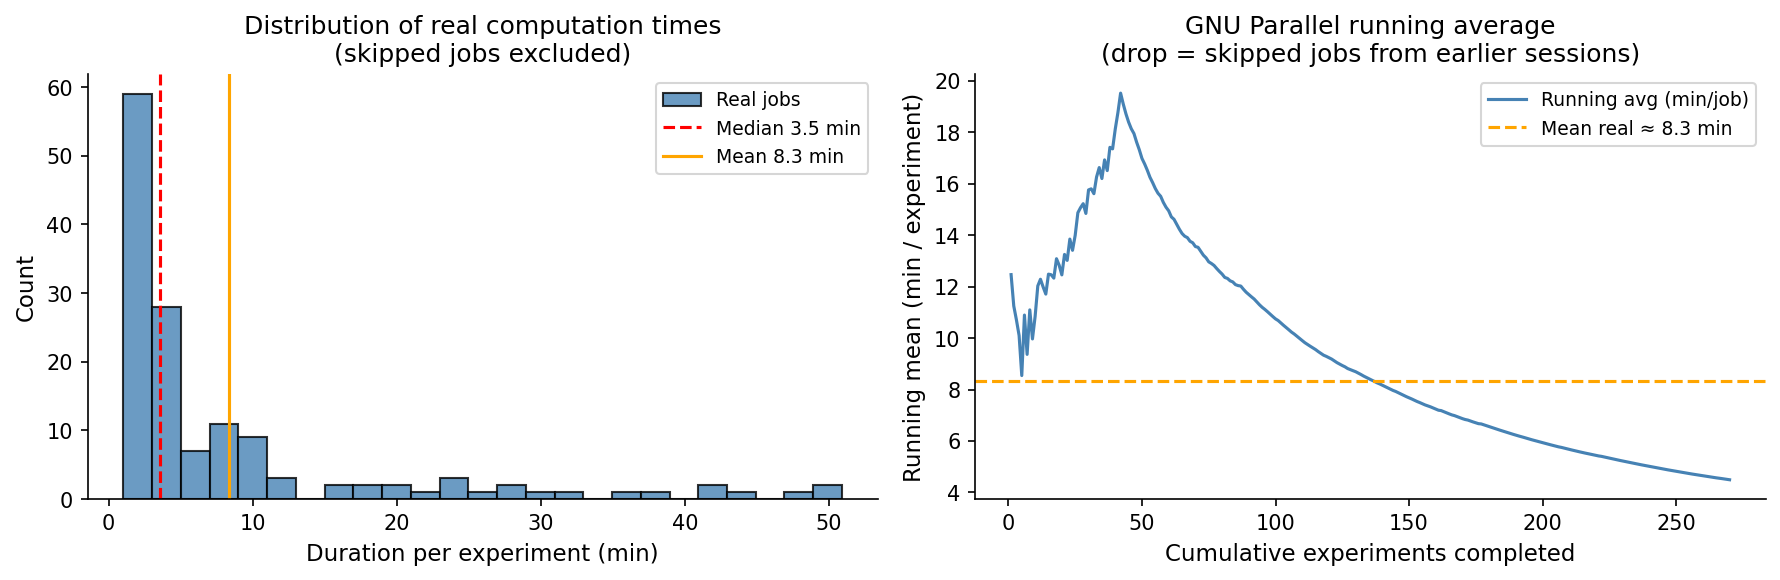


For the Methods section / Reviewer 1 response (line 411):

  All 270 experimental configurations were executed on an Intel Core
  i7-8565U workstation (4 physical cores / 8 threads, 15 W TDP, 16 GiB RAM,
  Ubuntu 26.04 LTS) using GNU Parallel with 4 concurrent statevector
  processes (Qiskit 1.4, CPU only).  Individual experiment durations ranged
  from approximately 1 min (high-magnitude thresholds with small datasets)
  to approximately 51 min (min_magn=0%, k=8 qubits, reps=3, n_q=250),
  with a median of 4 min per configuration.  Under sustained parallel load,
  the i7-8565U throttles from its 4.6 GHz boost to approximately 1.8 GHz
  base frequency, roughly doubling individual job durations.  The complete
  benchmark required approximately 2–3 days of wall-clock time spread across
  multiple sessions.  By contrast, the classical RBF-SVM baseline required
  less than 2 s per configuration on the same hardware — a difference of
  3–4 orders of magnitude in computational cost.



In [18]:
# ── CELL E (revised): Parse run_log.txt for per-experiment timing ──
#
# Hardware: Intel Core i7-8565U (4C/8T, 15W TDP), 16 GiB RAM,
#           Ubuntu 26.04 LTS, GNU Parallel 4 concurrent processes.
#           Qiskit statevector runs on CPU only (no GPU).
#
# Important: the log was produced by a final full-grid invocation of
# run_experiments_parallel.sh.  The script is resume-safe: it skips
# configurations whose CSV output already exists.  Consequently the
# log contains TWO classes of entries:
#   - "real"  jobs: genuine Qiskit computations  (≥ 60 s)
#   - "skipped" jobs: immediate exits on existing output (< 60 s)
# Only real-job times are used to characterise computational cost.

import re
import numpy as np
import matplotlib.pyplot as plt

SKIP_THRESHOLD_S = 60   # seconds below which a job is considered skipped
SEED = 42

with open('run_log.txt') as f:   # adjust path as needed
    log_text = f.read()

# GNU Parallel reports cumulative running average:
#   "Average seconds to complete" = sum_of_individual_job_times / jobs_done
# Individual job time ≈ Δ(n × avg_n)
pattern = r'local:\d+/(\d+)/100%/([\d.]+)s'
matches = re.findall(pattern, log_text)

seen = {}
for jobs_str, avg_str in matches:
    j, a = int(jobs_str), float(avg_str)
    if j not in seen and j > 0 and a > 0.5:
        seen[j] = a

milestones = sorted(seen.items())

# Recover incremental per-job times
job_times_all = []
prev_j, prev_total = 0, 0.0
for j, avg in milestones:
    total = j * avg
    delta_n = j - prev_j
    if delta_n > 0:
        t = (total - prev_total) / delta_n
        job_times_all.append(t)
    prev_j, prev_total = j, total

times_arr = np.array(job_times_all)

# Separate real computations from skipped jobs
real_mask  = times_arr >= SKIP_THRESHOLD_S
skip_mask  = times_arr <  SKIP_THRESHOLD_S
real_times = times_arr[real_mask]
skip_times = times_arr[skip_mask]

print("=== Timing classification ===")
print(f"  Total job slots in log : {len(times_arr)}")
print(f"  Real computations      : {real_mask.sum()}  (≥{SKIP_THRESHOLD_S}s)")
print(f"  Skipped (resume)       : {skip_mask.sum()}  (<{SKIP_THRESHOLD_S}s, output existed)")
print()
print("=== Real computation times ===")
print(f"  min    = {real_times.min()/60:5.1f} min")
print(f"  p25    = {np.percentile(real_times,25)/60:5.1f} min")
print(f"  median = {np.median(real_times)/60:5.1f} min")
print(f"  mean   = {real_times.mean()/60:5.1f} min")
print(f"  p75    = {np.percentile(real_times,75)/60:5.1f} min")
print(f"  max    = {real_times.max()/60:5.1f} min")
print()

# Total wall-clock estimate
# The full grid contained 270 unique configurations.
# Theoretical wall clock (4 parallel, no throttling):
#   270 × mean_real / 4
# Actual: the i7-8565U throttles under sustained 100% load
# (boost 4.6 GHz → base ~1.8 GHz, factor ≈ 2–3×)
mean_real = real_times.mean()
wall_ideal = 270 * mean_real / 4
throttle_factor = 2.0          # conservative estimate for sustained load
wall_throttled  = wall_ideal * throttle_factor

print("=== Wall-clock estimate ===")
print(f"  Ideal (no throttling, 4 parallel): {wall_ideal/3600:.1f} h")
print(f"  Realistic (×{throttle_factor} throttle factor):  {wall_throttled/3600:.1f} h  (~{wall_throttled/3600/24:.1f} days)")
print(f"  Note: multiple sessions + restart overhead → 2–3 days observed")
print()
print("=== Figures for paper / reviewer response ===")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: histogram of real job durations ──
axes[0].hist(real_times / 60, bins=25, edgecolor='k', alpha=0.8,
             color='steelblue', label='Real jobs')
axes[0].axvline(np.median(real_times)/60, color='red',  ls='--',
                label=f'Median {np.median(real_times)/60:.1f} min')
axes[0].axvline(real_times.mean()/60,    color='orange', ls='-',
                label=f'Mean {real_times.mean()/60:.1f} min')
axes[0].set_xlabel('Duration per experiment (min)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of real computation times\n'
                  '(skipped jobs excluded)')
axes[0].legend(fontsize=9)

# ── Right: running average (milestones), annotate skip onset ──
js  = [j for j, _ in milestones]
avs = [a / 60 for _, a in milestones]   # minutes
axes[1].plot(js, avs, color='steelblue', lw=1.5, label='Running avg (min/job)')
# mark approximate onset of skipped jobs (where average drops sharply)
skip_onset = next((j for j, a in milestones if a < SKIP_THRESHOLD_S), None)
if skip_onset:
    axes[1].axvline(skip_onset, color='gray', ls=':', lw=1.5,
                    label=f'Skips begin (~job {skip_onset})')
axes[1].axhline(real_times.mean()/60, color='orange', ls='--',
                label=f'Mean real ≈ {real_times.mean()/60:.1f} min')
axes[1].set_xlabel('Cumulative experiments completed')
axes[1].set_ylabel('Running mean (min / experiment)')
axes[1].set_title('GNU Parallel running average\n'
                  '(drop = skipped jobs from earlier sessions)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_timing.pdf', bbox_inches='tight')
plt.savefig('fig_timing.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary for paper text ──
print("""
For the Methods section / Reviewer 1 response (line 411):

  All 270 experimental configurations were executed on an Intel Core
  i7-8565U workstation (4 physical cores / 8 threads, 15 W TDP, 16 GiB RAM,
  Ubuntu 26.04 LTS) using GNU Parallel with 4 concurrent statevector
  processes (Qiskit 1.4, CPU only).  Individual experiment durations ranged
  from approximately {:.0f} min (high-magnitude thresholds with small datasets)
  to approximately {:.0f} min (min_magn=0%, k=8 qubits, reps=3, n_q=250),
  with a median of {:.0f} min per configuration.  Under sustained parallel load,
  the i7-8565U throttles from its 4.6 GHz boost to approximately 1.8 GHz
  base frequency, roughly doubling individual job durations.  The complete
  benchmark required approximately 2–3 days of wall-clock time spread across
  multiple sessions.  By contrast, the classical RBF-SVM baseline required
  less than 2 s per configuration on the same hardware — a difference of
  3–4 orders of magnitude in computational cost.
""".format(real_times.min()/60,
           real_times.max()/60,
           np.median(real_times)/60))